In [555]:
import matplotlib.pyplot as plt
import numpy as np
import math

import sys
sys.path.append('../../')

from common import *

# Сцинтиллятор

In [556]:
P_atm = 97.7 * 1000 # pa
P_atm_torr = 727.9 # torr
P_atm = np.mean([P_atm, P_atm_torr * 0.133 * 1000])
P_atm_torr = P_atm / 1000 / 0.133
(P_atm, P_atm_torr)

(np.float64(97255.35), np.float64(731.2432330827068))

In [557]:
delta_P = [     -710,      -700,      -690,      -680,      -670,      -660,      -650,      -640,      -630,      -620,      -610,      -600,      -590,      -580,      -570,      -550,      -530,      -510,       -490,      -470] # torr
N       = [3697 / 10, 3406 / 10, 3337 / 10, 3157 / 10, 3035 / 10, 2901 / 10, 2725 / 10, 2569 / 10, 4054 / 16, 4544 / 20, 3208 / 15, 3779 / 20, 2741 / 15, 2960 / 20, 2793 / 20, 2988 / 30, 2668 / 40, 2586 / 70, 1777 / 100, 491 / 100] # per sec
delta_P_err = [1] * len(delta_P)
N_err = [1] * len(N)

P = np.array(delta_P) * 0.133 * 1000 + P_atm # to kPa + atm
P_err = np.array(delta_P) * 0.133 * 1000
N = np.array(N)

(<Figure size 800x500 with 1 Axes>, <Axes: >)

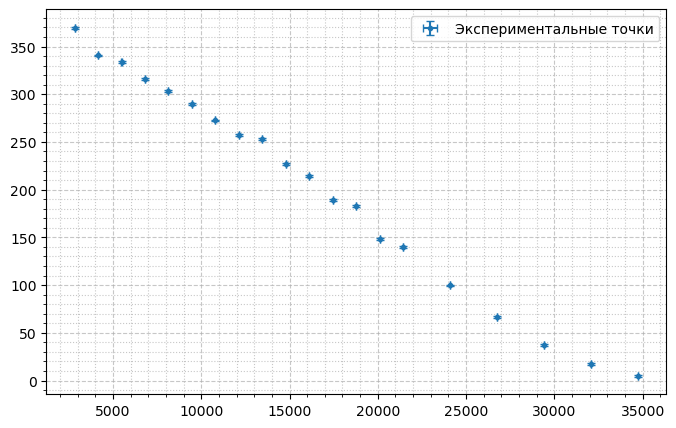

In [558]:
plot(P, N, delta_P_err, N_err, "", "", "")

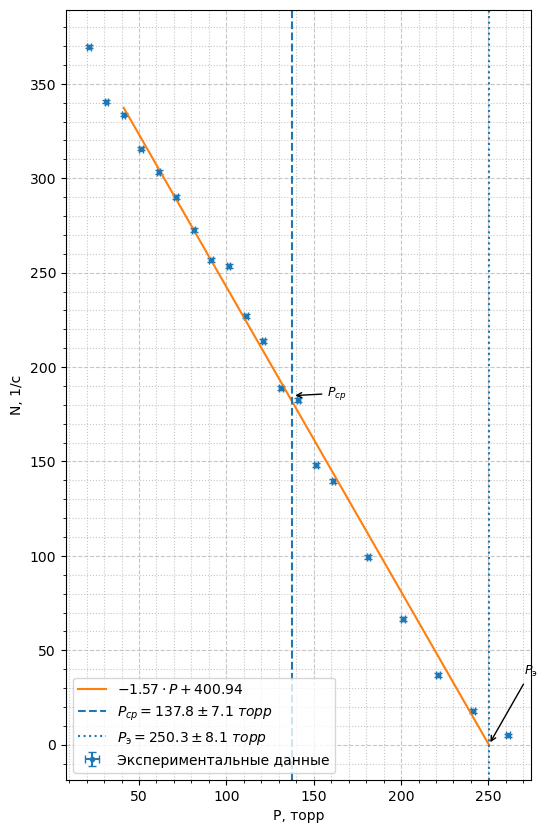

P_cp   = 137.8 $\pm$ 7.1 торр
P_extr = 250.3 $\pm$ 8.1 торр
R_cp   (эксп.) = 1.696 $\pm$ 0.088 см
R_extr (эксп.) = 3.081 $\pm$ 0.100см
R_cp   (760 торр, 15°C) = 1.594 см
R_extr (760 торр, 15°C) = 2.894 см
R_cp_mass   = 0.0020 г/см²
R_extr_mass = 0.0035 г/см²


In [559]:
# давление в торр

P = np.array(delta_P) + P_atm_torr
N_arr = np.array(N)

fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(10)

ax.errorbar(P, N_arr, xerr=delta_P_err, yerr=N_err, fmt='.', capsize=3, label='Экспериментальные данные')
ax.set_xlabel('P, торр')
ax.set_ylabel('N, 1/с')
ax.grid(True)

# средний пробег: по уровню N_max/2
N_max = N_arr.max()
N_half = N_max / 2
P_mean = np.interp(N_half, N_arr[::-1], P[::-1])


i_max = np.argmax(N_arr)

# погрешность максимума (если есть массив N_err)
sigma_Nmax = np.sqrt(N_err[i_max]**2 + (N_arr[0] - N_arr[1])**2)
sigma_Nhalf = sigma_Nmax / 2

# численная производная dN/dP
dN_dP = np.gradient(N_arr, P)

# индекс точки, ближайшей к P_mean
i_mean = np.argmin(np.abs(P - P_mean))

slope = dN_dP[i_mean]  # оценка dN/dP в точке P_mean
P_mean_err = sigma_Nhalf / abs(slope)

P_tail = P[2:-5]
N_tail = N_arr[2:-5]

# линейная экстраполяция, проходящая через точку (P_mean, N_half)
x = P_tail - P_mean
y = N_tail - N_half
m_tail = np.sum(x * y) / np.sum(x**2)
b_tail = N_half - m_tail * P_mean

# давление, при котором прямая падает до N = 0
P_ext = -b_tail / m_tail

k, b, kerr, berr = LeastSquares(P_tail, N_tail)
P_ext = -b / k
P_ext_err = np.sqrt((berr / k)**2 + (b * kerr / k**2)**2)

P_fit_tail = np.linspace(P_tail[0], P_ext, 200)
N_fit_tail = k * P_fit_tail + b

ax.plot(P_fit_tail, N_fit_tail, label=f'${round(m_tail, 2)} \\cdot P + {round(b_tail, 2)}$')
ax.axvline(P_mean, linestyle='--', label=f'$P_{{cp}} = {round(P_mean, 1)} \\pm {round(P_mean_err, 1)} ~торр$')
ax.axvline(P_ext, linestyle=':', label=f'$P_{{\\mathrm{{э}}}} = {round(P_ext, 1)} \\pm {round(P_ext_err, 1)} ~торр$')

y_mean = N_half
y_ext = 0.0

ax.annotate('$P_{cp}$', xy=(P_mean, y_mean), xytext=(P_mean + 20, y_mean),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.annotate('$P_{\\mathrm{э}}$', xy=(P_ext, y_ext), xytext=(P_ext + 20, y_ext + N_max*0.1),
            arrowprops=dict(arrowstyle='->'), fontsize=9)

ax.minorticks_on()
ax.grid(True, linestyle='--', alpha=0.7, which='major')
ax.grid(True, linestyle=':',  alpha=0.7, which='minor')
ax.legend()
plt.show()

# длина камеры (расстояние препарат–люминофор)
L_cm = 9.0
P_atm = P_atm_torr

# пробеги при условиях опыта (см)
R_mean_exp = L_cm * P_mean / P_atm
R_mean_exp_err = L_cm * P_mean_err / P_atm
R_ext_exp = L_cm * P_ext / P_atm
R_ext_exp_err = L_cm * P_ext_err / P_atm

# пересчёт к 760 торр и 15 °C
T_exp_C = 22.0
T_exp = 273.15 + T_exp_C
T_norm = 273.15 + 15.0
P_norm = 760.0

R_mean_norm = R_mean_exp * (P_atm / P_norm) * (T_norm / T_exp)
R_ext_norm = R_ext_exp * (P_atm / P_norm) * (T_norm / T_exp)

# пробег в г/см^2 (ρ воздуха при 15 °C ~ 1.225e-3 г/см^3)
rho_air = 1.225e-3
R_mean_g = R_mean_norm * rho_air
R_ext_g = R_ext_norm * rho_air

print(f"P_cp   = {P_mean:.1f} $\\pm$ {P_mean_err:.1f} торр")
print(f"P_extr = {P_ext:.1f} $\\pm$ {P_ext_err:.1f} торр")
print(f"R_cp   (эксп.) = {R_mean_exp:.3f} $\\pm$ {R_mean_exp_err:.3f} см")
print(f"R_extr (эксп.) = {R_ext_exp:.3f} $\\pm$ {R_ext_exp_err:.3f}см")
print(f"R_cp   (760 торр, 15°C) = {R_mean_norm:.3f} см")
print(f"R_extr (760 торр, 15°C) = {R_ext_norm:.3f} см")
print(f"R_cp_mass   = {R_mean_g:.4f} г/см²")
print(f"R_extr_mass = {R_ext_g:.4f} г/см²")

In [560]:
k, kerr

(np.float64(-1.6133424908424958), np.float64(0.04816503295698267))

In [561]:
b, berr

(np.float64(403.8150098426015), np.float64(5.198743707919379))

In [562]:
alpha = 2/3

R_mean_norm_err = R_mean_norm * P_mean_err / P_mean
R_ext_norm_err = R_ext_norm * P_ext_err / P_ext

E_cp = (R_mean_norm / 0.32)**alpha
E_ext = (R_ext_norm / 0.32)**alpha

E_cp_err = (2/3) * E_cp * (R_mean_norm_err / R_mean_norm)
E_ext_err = (2/3) * E_ext * (R_ext_norm_err / R_ext_norm)

print(f"E_cp   = {E_cp:.3f} ± {E_cp_err:.3f} МэВ")
print(f"E_extr = {E_ext:.3f} ± {E_ext_err:.3f} МэВ")

E_cp   = 2.916 ± 0.100 МэВ
E_extr = 4.341 ± 0.094 МэВ


# Ионизационная камера

In [563]:
I       = [  28,   98,  168,  243,  324,  363,  405,  447,  491,  535,  580,  627,  672,  715,  758,  787,  810,  820,  820,  810,  806, 795, 795, 790, 780] # pA
delta_P = [-700, -650, -600, -550, -500, -475, -450, -425, -400, -375, -350, -325, -300, -275, -250, -225, -200, -175, -150, -125, -100, -75, -50, -25,   0] # torr
I_err = [1] * len(I)
delta_P_err = [1] * len(delta_P)
P = np.array(delta_P) + P_atm_torr
I = np.array(I)

(<Figure size 800x500 with 1 Axes>, <Axes: >)

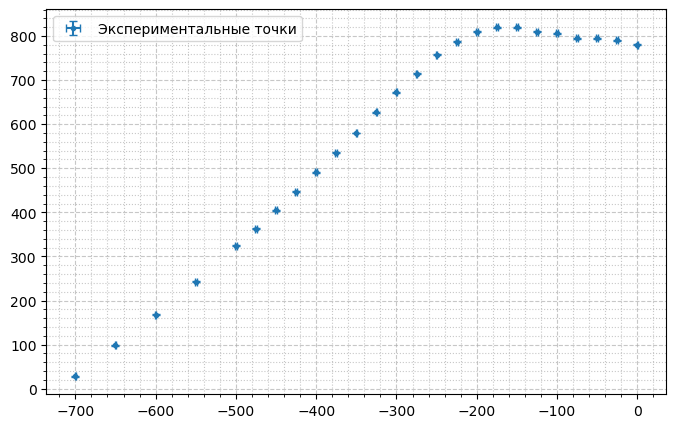

In [564]:
plot(delta_P, I, delta_P_err, I_err, "", "", "")

нет плато т к рекомбинация

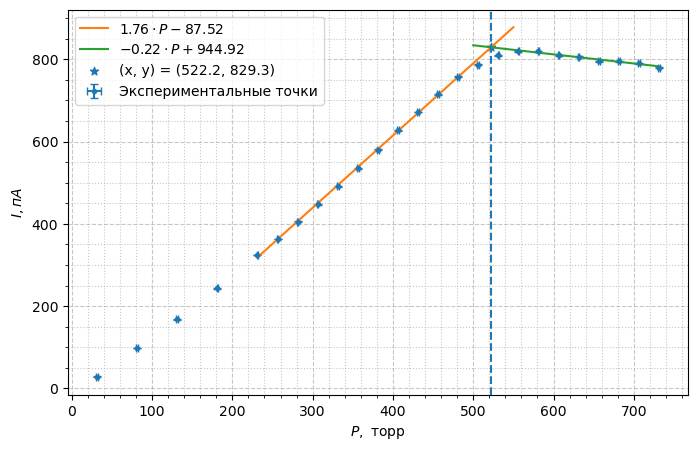

In [565]:
plot(P, I, delta_P_err, I_err, "$P, ~\\text{торр}$", "$I, пА$", "")

k1, b1, kerr1, berr1 = LeastSquares(P[4:-10], I[4:-10])

P_fit = np.linspace(P[4], 550, 200)
I_fit = k1 * P_fit + b1
plt.plot(P_fit, I_fit, label=f'${round(k1, 2)} \\cdot P {round(b1, 2)}$')

k2, b2, kerr2, berr2 = LeastSquares(P[-8:-1], I[-8:-1])
P_fit = np.linspace(500, P[-1], 200)
I_fit = k2 * P_fit + b2
plt.plot(P_fit, I_fit, label=f'${round(k2, 2)} \\cdot P + {round(b2, 2)}$')

x_intersect = (b1 - b2) / (k2 - k1)
y_intersect = k1 * x_intersect + b1
plt.scatter([x_intersect], [y_intersect], marker="*", label=f"(x, y) = ({x_intersect:.1f}, {y_intersect:.1f})")
plt.axvline(x_intersect, linestyle="--")
plt.legend()
plt.show()

In [566]:
P_0 = x_intersect
P_0_err = np.sqrt(((kerr1 * (b1 - b2) / (k1 - k2)**2))**2 +
                  ((kerr2 * (b1 - b2) / (k1 - k2)**2))**2 +
                  (berr1 / (k1 - k2))**2 +
                  (berr2 / (k1 - k2))**2)
P_0, P_0_err

(np.float64(522.2097714381309), np.float64(9.833406398772887))

In [567]:
R_ext_exp, R_ext_exp_err = ((10 - 0.5) / 2 * P_0 / P_atm_torr, (10 - 0.5) / 2 * P_0_err / P_atm_torr)

In [568]:
(rho_air * (10 - 0.5) / 2 * P_0 / P_atm_torr, rho_air * (10 - 0.5) / 2 * P_0_err / P_atm_torr)

(np.float64(0.004155399968278331), np.float64(7.824774424461323e-05))

In [569]:
# пересчёт к 760 торр и 15 °C
T_exp_C = 22.0
T_exp = 273.15 + T_exp_C
T_norm = 273.15 + 15.0
P_norm = 760.0

R_ext_norm = R_ext_exp * (P_atm_torr / P_norm) * (T_norm / T_exp)
R_ext_norm_err = R_ext_exp_err * (P_atm_torr / P_norm) * (T_norm / T_exp)
R_ext_norm * rho_air, R_ext_norm_err * rho_air

(np.float64(0.0039033449815533273), np.float64(7.350145404694326e-05))

In [570]:
alpha = 2/3

E_ext = (R_ext_norm / 0.32)**alpha

E_ext_err = (2/3) * E_ext * (R_ext_norm_err / R_ext_norm)

print(f"E_extr = {E_ext:.3f} ± {E_ext_err:.3f} МэВ")

E_extr = 4.628 ± 0.058 МэВ


In [571]:
nu = 370 * 4 * np.pi * 2.44 * 10**4 * 365 * 24 * 3600 / (0.04 * 6.02 * 10**23 * np.log(2))
nu

np.float64(2.1435127826546112e-07)

In [572]:
R_ext_norm / (0.8)

np.float64(3.983005083217681)

In [573]:
R_ext_norm_err / (0.8)

np.float64(0.07500148372137067)